In [2]:
#STEP 1 — IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from xgboost import XGBRegressor

import joblib


In [3]:
# STEP 2 — LOAD DATASET

df = pd.read_csv('data/train.csv')

print(df.head())


   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

In [4]:
# STEP 3 — DATA CLEANING

# Fill numeric missing values

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])



In [5]:
# STEP 4 — FEATURE ENGINEERING

df['HouseAge'] = 2025 - df['YearBuilt']

df['TotalArea'] = df['1stFlrSF'] + df['2ndFlrSF']



In [6]:
# STEP 5 — ENCODE CATEGORICAL DATA

df = pd.get_dummies(df, drop_first=True)



In [8]:
# STEP 6 — DEFINE X AND y

X = df.drop('SalePrice', axis=1)

y = df['SalePrice']




















In [9]:
# STEP 7 — TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
# STEP 8 — BUILD MODEL

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [11]:
# STEP 9 — PREDICTIONS

predictions = model.predict(X_test)

In [12]:
# STEP 10 — EVALUATION

r2 = r2_score(y_test, predictions)

print("R2 Score:", r2)

rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("RMSE:", rmse)


# R² Formula

# :contentReference[oaicite:0]{index=0}


# RMSE Formula

# :contentReference[oaicite:1]{index=1}



R2 Score: 0.9131006002426147
RMSE: 25817.570451148185


In [13]:
# STEP 11 — FEATURE IMPORTANCE

importance = model.feature_importances_

feature_names = X.columns

feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_df = feature_df.sort_values(
    by='Importance',
    ascending=False
)

print(feature_df.head(10))



               Feature  Importance
4          OverallQual    0.275187
26          GarageCars    0.090669
38           TotalArea    0.086867
215   GarageFinish_Unf    0.079803
153       ExterQual_TA    0.045871
113   RoofMatl_CompShg    0.040172
191       CentralAir_Y    0.019231
213  GarageType_Detchd    0.017758
12         TotalBsmtSF    0.016440
16           GrLivArea    0.016154


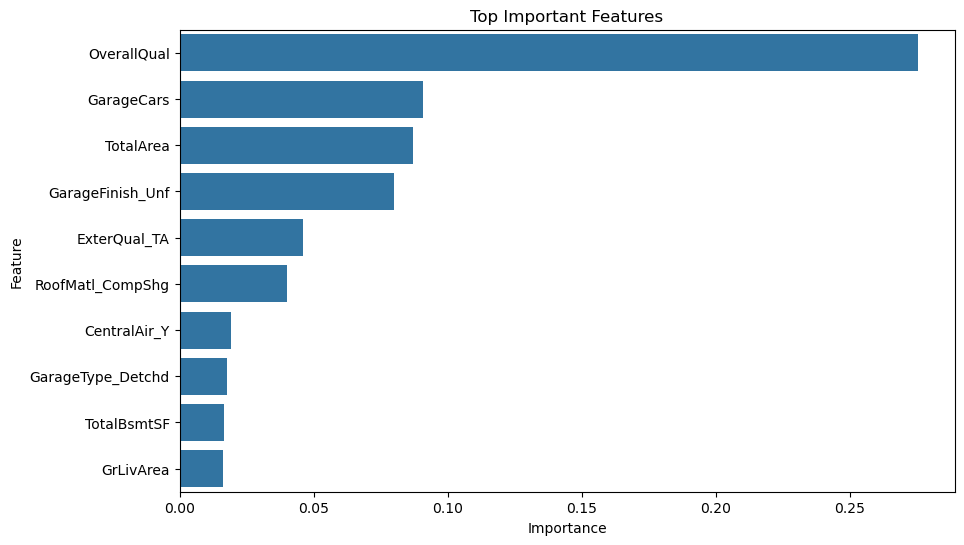

In [14]:
# STEP 12 — VISUALIZATION
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_df.head(10)
)

plt.title("Top Important Features")

plt.show()


In [15]:
# STEP 13 — SAVE MODEL

joblib.dump(model, 'house_price_model.pkl')

print("Model Saved Successfully")


Model Saved Successfully


In [16]:
# STEP 14 — SAMPLE PREDICTION

sample = X_test.iloc[:1]

sample_prediction = model.predict(sample)

print("Predicted House Price:", sample_prediction)



Predicted House Price: [139647.2]


In [18]:
# PROJECT COMPLETED

print("HOUSE PRICE PREDICTION PROJECT COMPLETED")

HOUSE PRICE PREDICTION PROJECT COMPLETED
